# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada o algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [3]:
#seu código aqui
X_test = pd.read_csv("X_test.csv", delimiter=',')
X_train = pd.read_csv("X_train_balanced.csv", delimiter=',')
y_test = pd.read_csv("y_test.csv", delimiter=',')
y_train = pd.read_csv("y_train_balanced.csv", delimiter=',')

In [4]:
X_test

,Age,Income,Gender_encoded,Marital_Status_encoded,Number of Children_1,Number of Children_2,Number of Children_3,Home_Ownership_encoded,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree
0,25,55000.0,0,1,0,0,0,1,1,0,0,0
1,48,87500.0,0,0,1,0,0,0,0,1,0,0
2,26,55000.0,0,0,1,0,0,0,1,0,0,0
3,39,62500.0,0,0,0,1,0,0,1,0,0,0
4,35,90000.0,0,0,1,0,0,0,0,1,0,0
5,25,55000.0,0,1,0,0,0,1,1,0,0,0
6,48,82500.0,0,0,1,0,0,0,0,1,0,0
7,48,82500.0,0,0,1,0,0,0,0,1,0,0
8,36,95000.0,0,0,0,1,0,0,0,0,0,1
9,36,95000.0,0,0,1,0,0,0,0,0,1,0


In [5]:
y_test

,Credit_Score_encoded
0,1
1,2
2,1
3,2
4,2
5,1
6,2
7,2
8,2
9,2


In [6]:
X_train

,Age,Income,Gender_encoded,Marital_Status_encoded,Number of Children_1,Number of Children_2,Number of Children_3,Home_Ownership_encoded,Education_Bachelor's Degree,Education_Doctorate,Education_High School Diploma,Education_Master's Degree
0,26,45000.000000,0,1,0,0,0,1,0,0,0,0
1,29,27500.000000,0,1,0,0,0,1,0,0,1,0
2,25,62500.000000,0,1,0,0,0,1,1,0,0,0
3,29,68000.000000,0,0,0,1,0,0,0,1,0,0
4,31,65000.000000,1,1,0,0,0,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
247,29,43703.466973,0,1,0,0,0,1,0,0,0,0
248,34,47500.000000,1,1,0,0,0,1,0,0,0,0
249,29,57500.000000,0,1,0,0,0,1,0,0,0,0
250,25,60063.547817,0,1,0,0,0,1,1,0,0,0


In [7]:
y_train

,Credit_Score_encoded
0,1
1,0
2,1
3,1
4,1
...,...
247,1
248,1
249,1
250,1


In [9]:
# Contar o número de exemplos de cada classe em y_train
train_balance = y_train.value_counts()
print("Balanceamento em y_train:")
print(train_balance)

# Contar o número de exemplos de cada classe em y_test
test_balance = y_test.value_counts()
print("\nBalanceamento em y_test:")
print(test_balance)

Balanceamento em y_train:
Credit_Score_encoded
0                       84
1                       84
2                       84
Name: count, dtype: int64

Balanceamento em y_test:
Credit_Score_encoded
2                       29
0                        6
1                        6
Name: count, dtype: int64


# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

#Sua resposta aqui
Para aplicar o algoritmo de árvore de decisão, primeiro é necessário organizar os dados, separando as variáveis de entrada (X) e a variável alvo (y). Depois disso, os dados são divididos em dois grupos: treino e teste. O treino serve para o modelo aprender os padrões, enquanto o teste é usado para verificar se ele funciona bem com novos dados.
Em seguida, criamos o modelo de árvore de decisão, definindo alguns parâmetros, como o critério de divisão (gini ou entropy). Depois, treinamos o modelo com o método fit, fazendo com que ele aprenda regras a partir dos dados.
Com o modelo treinado, realizamos previsões usando os dados de teste com o método predict. Essas previsões são comparadas com os valores reais para avaliar o desempenho.
A avaliação é uma etapa muito importante. Para isso, usamos métricas como acurácia, matriz de confusão, precisão, recall e F1-score, que mostram o quanto o modelo está acertando e onde ele erra.
Se o modelo não tiver um bom resultado, é possível melhorá-lo ajustando alguns pontos, como a profundidade da árvore (max_depth), o número mínimo de amostras por nó, evitando o overfitting, balanceando os dados e escolhendo melhor as variáveis. 

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.

In [10]:
#seu código aqui

arvore_Credit_Score_encoded = DecisionTreeClassifier (criterion = 'gini', random_state = 0)

arvore_Credit_Score_encoded.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
previsoes = arvore_Credit_Score_encoded.predict(X_train[:10])
previsoes

array([1, 0, 1, 1, 1, 2, 2, 2, 1, 2])

In [14]:
y_train

,Credit_Score_encoded
0,1
1,0
2,1
3,1
4,1
...,...
247,1
248,1
249,1
250,1


In [11]:
print(arvore_Credit_Score_encoded.get_params())

{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 0, 'splitter': 'best'}


In [34]:
treino = arvore_Credit_Score_encoded.predict(X_train)
relatorio_treino = classification_report(y_train, treino)
print("Relatório de Classificação Treino:")
print(relatorio_treino)

Relatório de Classificação Treino:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        84
           1       1.00      1.00      1.00        84
           2       1.00      1.00      1.00        84

    accuracy                           1.00       252
   macro avg       1.00      1.00      1.00       252
weighted avg       1.00      1.00      1.00       252



# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

O modelo de árvore de decisão apresentou desempenho perfeito no conjunto de treino, com 100% de acurácia, precisão, recall e F1-score. Já no conjunto de teste, o modelo manteve um desempenho muito alto, com acurácia de 98%, indicando boa capacidade de generalização.

In [17]:
#seu código aqui
previsoes = arvore_Credit_Score_encoded.predict(X_test)
acuracia = accuracy_score(y_test, previsoes)
print("Acurácia:", acuracia)

Acurácia: 0.975609756097561


In [33]:
relatorio = classification_report(y_test, previsoes)
print("Relatório de Classificação Teste:")
print(relatorio)

Relatório de Classificação Teste:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       0.86      1.00      0.92         6
           2       1.00      0.97      0.98        29

    accuracy                           0.98        41
   macro avg       0.95      0.99      0.97        41
weighted avg       0.98      0.98      0.98        41



# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

Sim, a árvore de decisão apresentou profundidade de 5 níveis, indicando um modelo com complexidade moderada. Esse nível de profundidade permite capturar bem os padrões dos dados sem tornar o modelo excessivamente complexo.

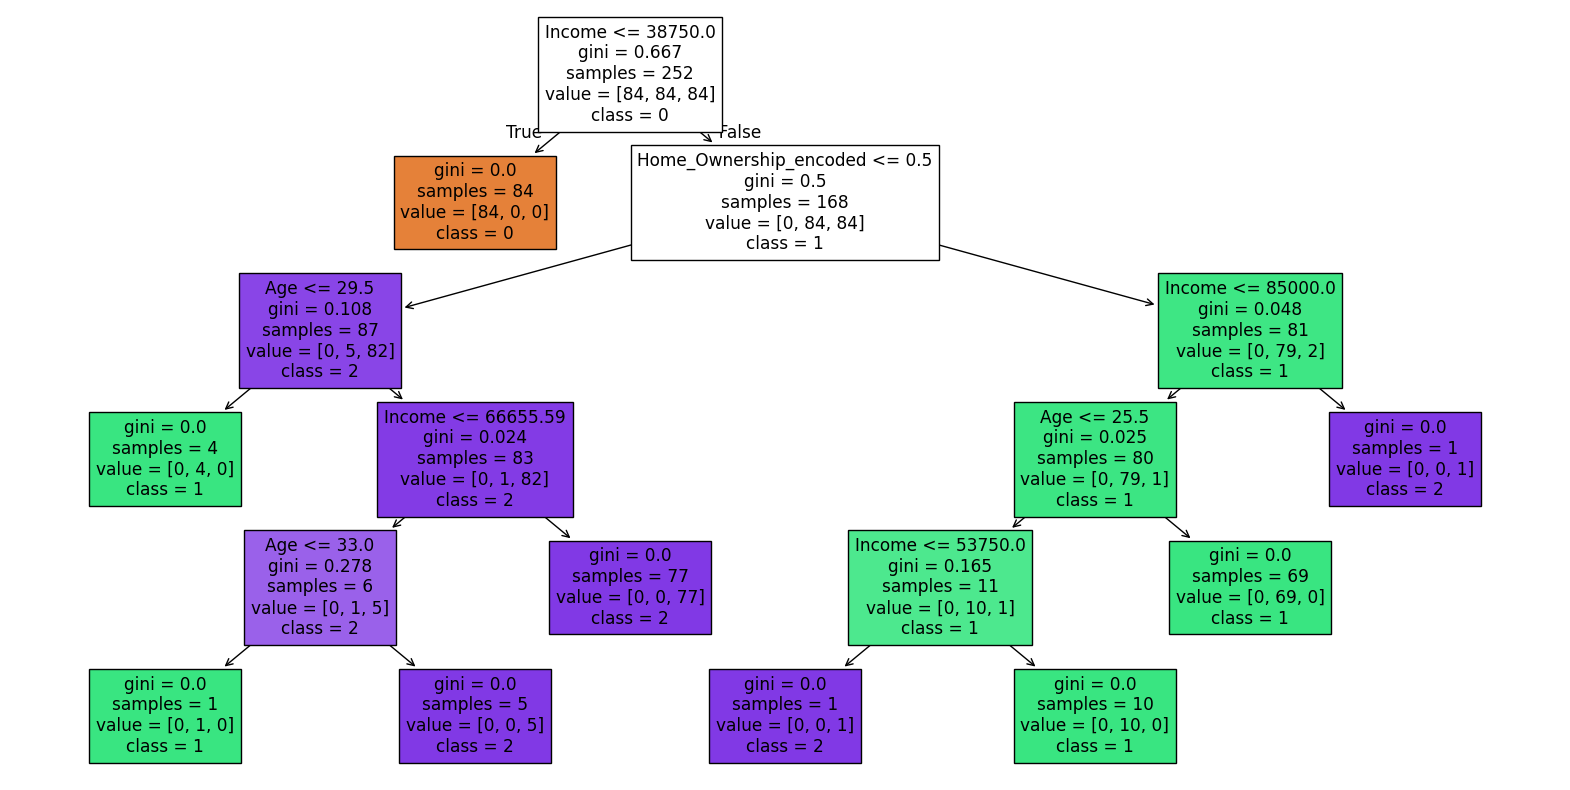

In [24]:
#seu código aqui
plt.figure(figsize=(20,10))
plot_tree(arvore_Credit_Score_encoded, filled=True, feature_names=X_train.columns, class_names=['0', '1', '2'])
plt.show()

In [25]:
arvore_Credit_Score_encoded.get_depth()

5

# 6) Identifique as 2 principais features do modelo.


As principais features são o Income(Salário Anual) e Home_Ownership_Encoded(Casa), isso nos mostra que esses fatores influenciam bastante na classificação do score de crédito.

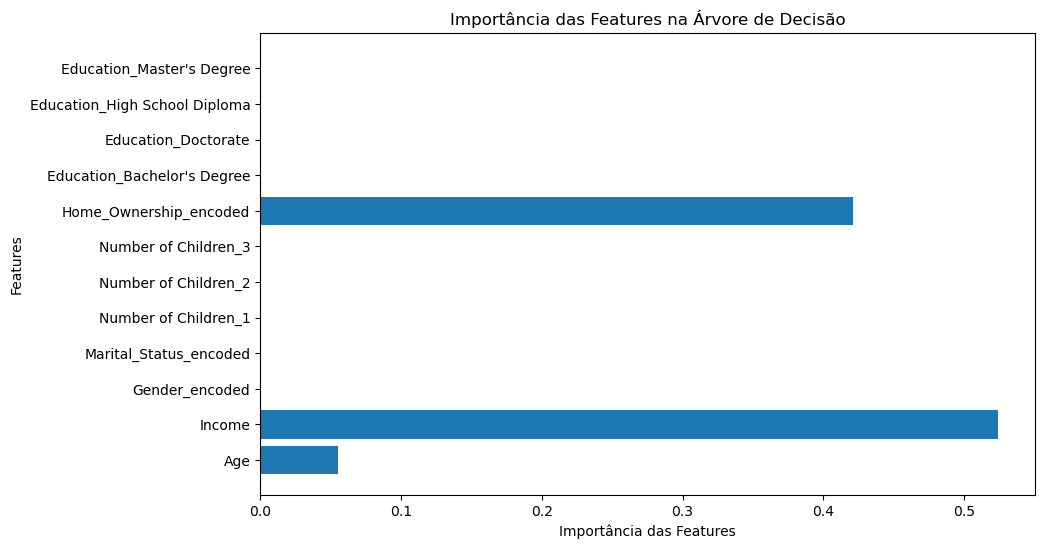

In [26]:
#seu código aqui

importancias_features = arvore_Credit_Score_encoded.feature_importances_

# Obtendo os nomes das características
nomes_features = X_train.columns

# Criando um gráfico de barras 
plt.figure(figsize=(10, 6))
plt.barh(nomes_features, importancias_features)
plt.xlabel('Importância das Features')
plt.ylabel('Features')
plt.title('Importância das Features na Árvore de Decisão')
plt.show()

# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

O modelo reduzido apresentou uma acurácia de 95% no conjunto de teste, indicando um bom desempenho geral, mesmo com menos variáveis.Entretanto a uma leve queda de desempenho, principalmente na classe 1, mostra que ao reduzir as variáveis o modelo perdeu um pouco de capacidade de distinção entre as classes. Ainda assim, o resultado continua satisfatório.

In [27]:
#seu código aqui
X_train_reduzido = X_train[['Income', 'Home_Ownership_encoded']]
X_test_reduzido = X_test[['Income', 'Home_Ownership_encoded']]

In [28]:
arvore_Credit_Score_encoded_reduzido = DecisionTreeClassifier (criterion = 'gini', random_state = 0)
arvore_Credit_Score_encoded_reduzido.fit(X_train_reduzido, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [29]:
previsoes_reduzido = arvore_Credit_Score_encoded_reduzido.predict(X_test_reduzido)

In [32]:
relatorio_reduzido = classification_report(y_test, previsoes_reduzido)
print("Relatório de Classificação Reduzido:")
print(relatorio_reduzido)

Relatório de Classificação Reduzido:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       0.83      0.83      0.83         6
           2       0.97      0.97      0.97        29

    accuracy                           0.95        41
   macro avg       0.93      0.93      0.93        41
weighted avg       0.95      0.95      0.95        41



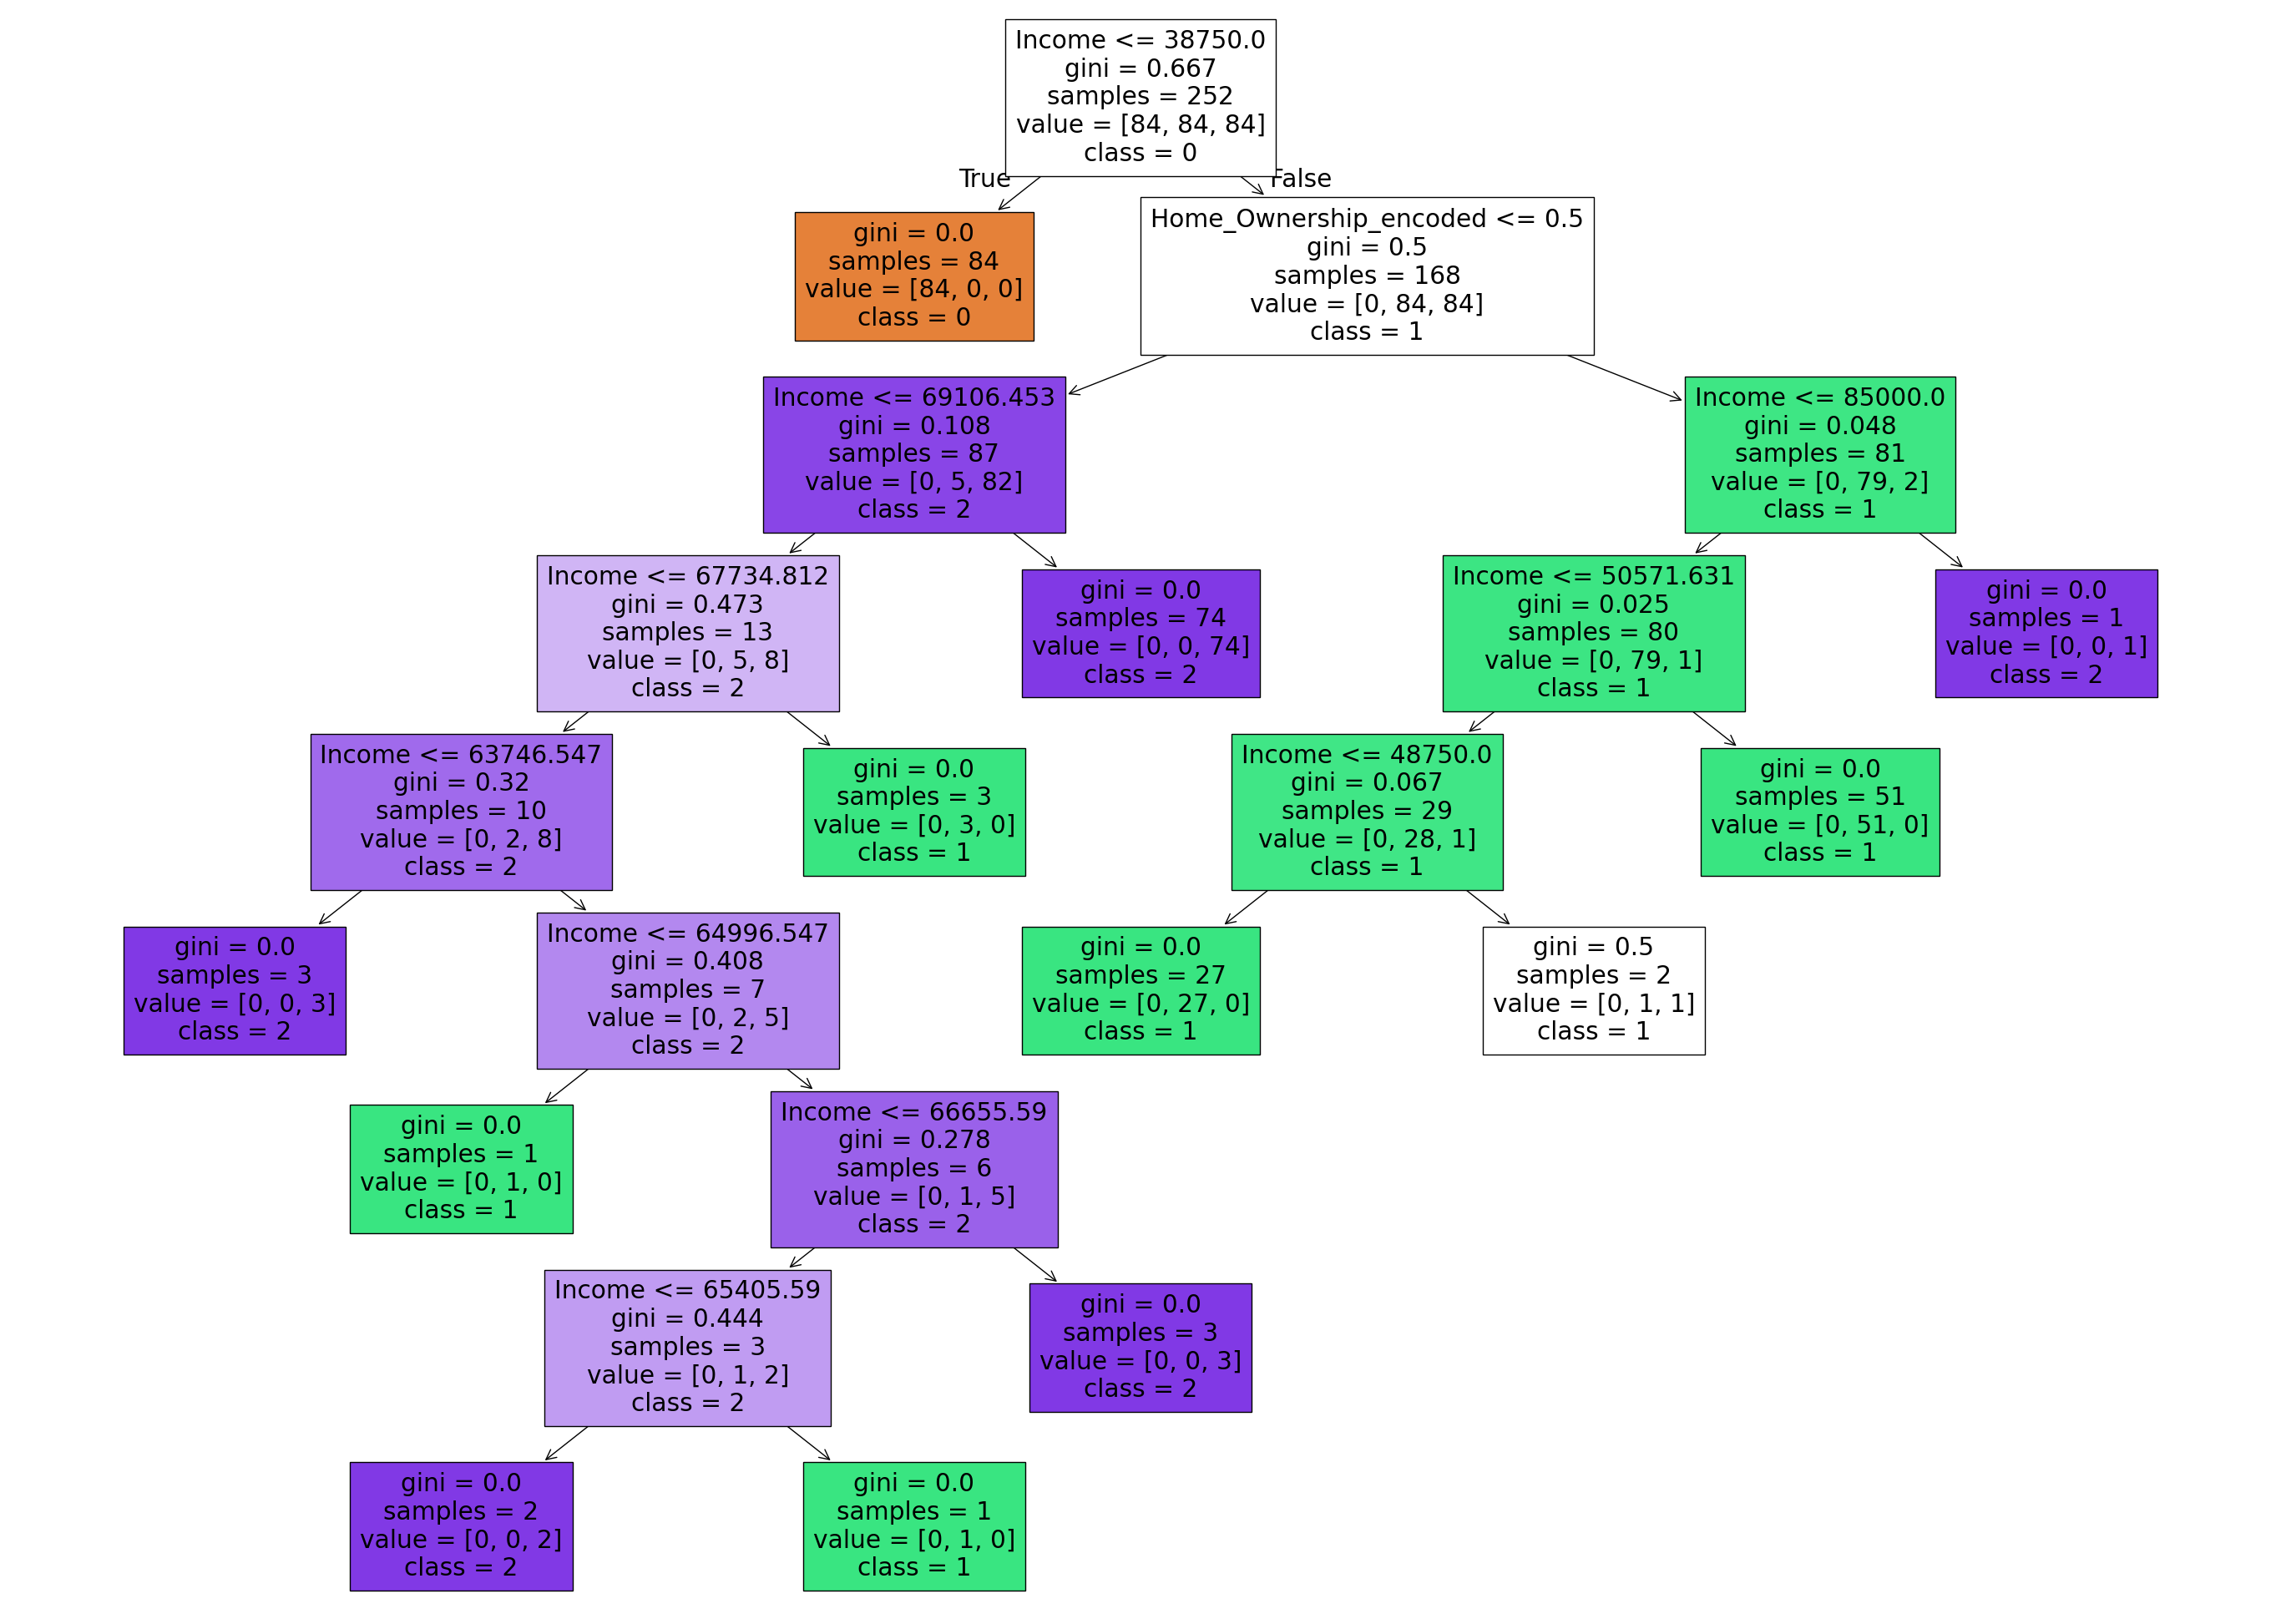

In [31]:
plt.figure(figsize=(35,25))
plot_tree(arvore_Credit_Score_encoded_reduzido, filled=True, feature_names=X_train_reduzido.columns, class_names=['0', '1', '2'])
plt.show()

# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

#Seu texto aqui

O modelo de árvore de decisão alcançou 100% de acurácia no treino e cerca de 98% no teste, mostrando excelente capacidade de aprendizado e boa generalização. Já o modelo Naive Bayes, embora também tenha apresentado bons resultados (acurácia de aproximadamente 97% e recall de 94,4%), teve um desempenho ligeiramente inferior. A árvore de decisão se mostrou mais adequada aos dados, pois apresentou maior acurácia e melhor desempenho geral nas métricas de avaliação. Isso indica que o modelo conseguiu representar melhor os padrões presentes no conjunto de dados em comparação ao Naive Bayes.